In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold

In [2]:
waka_dragon_df = pd.read_csv("data/waka_dragon_merged.csv")
mX_df = waka_dragon_df.loc[:, 'MW':]

In [3]:
waka_dragon_df.head()

,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,AMW,Sv,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,6.294,7.537,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,7.581,9.295,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,6.759,9.822,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,8.597,12.010,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,6.444,13.876,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [4]:
vY_Imax = waka_dragon_df['Imax']

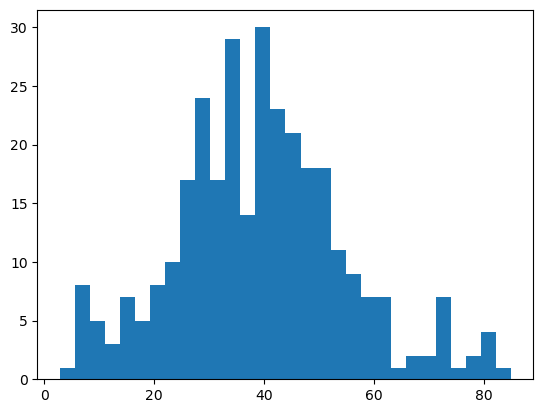

In [5]:
import matplotlib.pyplot as plt
plt.hist(vY_Imax, bins = 30)
plt.show()

In [ ]:
#first we remove features with zero variance
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0) #object 

mX1 = vt.fit_transform(mX_df) #returns NDArray

# mX1_df becomes the updated feature matrix
mX1_df = pd.DataFrame(
    mX1,
    columns=mX_df.columns[vt.get_support()],
    index=mX_df.index
)

print(mX1_df.shape)

(312, 2484)


In [7]:
# correlations matrix
corr_matrix = mX1_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95) # May be the correlation threshold should be lower
]

print(f"Descriptors to remove: {len(to_drop)}")

Descriptors to remove: 1650


In [8]:
# Dropping of high correlated descriptors
mX2_df = mX1_df.drop(columns=to_drop)
print(mX2_df.shape)

(312, 834)


In [9]:
xgb_reg = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(mX2_df, vY_Imax)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [10]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=mX2_df.columns
).sort_values(ascending=False)

importance.head(60)

MPC08             0.008404
ATS6m             0.004714
Vindex            0.004082
Eig07_AEA_dm_     0.003914
VE1_A             0.003811
Mor05m            0.003789
SpMaxA_AEA_dm_    0.003672
VE2_B_m_          0.003267
Mor08m            0.003093
SpMax1_Bh_m_      0.002923
RDF065s           0.002864
VE1_G_D           0.002551
VE2_B_v_          0.002536
RDF065u           0.002479
SM12_AEA_dm_      0.002352
Mor17m            0.002307
RDF010s           0.002297
Eig09_AEA_ri_     0.002289
HTm               0.002283
Eig04_AEA_dm_     0.002270
SM05_AEA_dm_      0.002264
Mor03v            0.002257
SpMin5_Bh_s_      0.002250
SpMax_L           0.002240
RDF050m           0.002213
SM15_AEA_bo_      0.002211
Mor11v            0.002156
HATS5u            0.002153
Mor31u            0.002149
SpMax2_Bh_s_      0.002149
Mor12u            0.002130
P_VSA_LogP_3      0.002127
R2s_              0.002117
H2m               0.002110
Mor32v            0.002100
H3m               0.002091
SdsCH             0.002083
H

In [11]:
top60_reg_features = importance.index[:60]

top60_reg_features

Index(['MPC08', 'ATS6m', 'Vindex', 'Eig07_AEA_dm_', 'VE1_A', 'Mor05m',
       'SpMaxA_AEA_dm_', 'VE2_B_m_', 'Mor08m', 'SpMax1_Bh_m_', 'RDF065s',
       'VE1_G_D', 'VE2_B_v_', 'RDF065u', 'SM12_AEA_dm_', 'Mor17m', 'RDF010s',
       'Eig09_AEA_ri_', 'HTm', 'Eig04_AEA_dm_', 'SM05_AEA_dm_', 'Mor03v',
       'SpMin5_Bh_s_', 'SpMax_L', 'RDF050m', 'SM15_AEA_bo_', 'Mor11v',
       'HATS5u', 'Mor31u', 'SpMax2_Bh_s_', 'Mor12u', 'P_VSA_LogP_3', 'R2s_',
       'H2m', 'Mor32v', 'H3m', 'SdsCH', 'HGM', 'H6s', 'ATSC8e', 'Mor17v',
       'VE2_G_D', 'Eig06_AEA_dm_', 'Eig02_EA_dm_', 'Mor02v', 'H7s', 'Mor03s',
       'R8u', 'R3s', 'H0m', 'MATS1v', 'P_VSA_ppp_ter', 'GATS6v', 'Mor28m',
       'VE3_RG', 'Eta_L_A', 'TDB03s', 'H3u', 'E2p', 'MLOGP'],
      dtype='str')

In [12]:
X_top60_reg = mX2_df[top60_reg_features].copy()

print(X_top60_reg.shape)

(312, 60)


In [13]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_reg,
    X_top60_reg,
    vY_Imax,
    scoring="neg_mean_absolute_error",
    cv=cv
)

print("CV MAE:", -scores.mean())
print("STD:", scores.std())

CV MAE: 7.957742905936605
STD: 0.8245819580930289


In [14]:
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=mX2_df.columns
).sort_values(ascending=False)

In [15]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(10, 61, 5):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

,n_features,MAE,R2
0,10,8.879124,0.467565
1,15,8.867067,0.460002
2,20,8.446710,0.502889
3,25,8.651833,0.488059
4,30,8.284564,0.516188
5,35,8.314792,0.522879
6,40,7.990470,0.548411
7,45,7.888934,0.561290
8,50,8.068308,0.544062
9,55,8.030042,0.553890


In [16]:
results_df.sort_values('MAE')

,n_features,MAE,R2
7,45,7.888934,0.561290
10,60,7.959306,0.551362
6,40,7.990470,0.548411
9,55,8.030042,0.553890
8,50,8.068308,0.544062
4,30,8.284564,0.516188
5,35,8.314792,0.522879
2,20,8.446710,0.502889
3,25,8.651833,0.488059
1,15,8.867067,0.460002


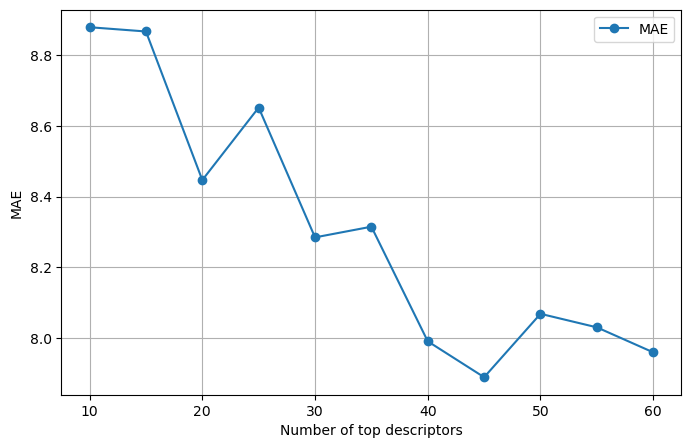

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['MAE'],
    marker='o',
    label='MAE'
)

plt.xlabel('Number of top descriptors')
plt.ylabel('MAE')
plt.grid(True)
plt.legend()

plt.show()

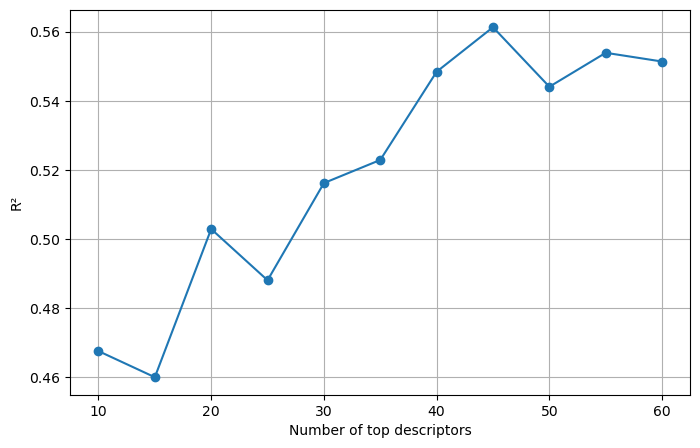

In [18]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['n_features'],
    results_df['R2'],
    marker='o'
)

plt.xlabel('Number of top descriptors')
plt.ylabel('R²')
plt.grid(True)

plt.show()

In [1]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for n_features in range(35, 57, 1):

    top_features = importance.index[:n_features]

    X_subset = mX2_df[top_features]

    model = XGBRegressor(
        objective='reg:absoluteerror',
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X_subset,
        vY_Imax,
        cv=cv
    )

    mae = mean_absolute_error(vY_Imax, y_pred)
    r2 = r2_score(vY_Imax, y_pred)

    results.append({
        'n_features': n_features,
        'MAE': mae,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df

NameError: name 'importance' is not defined

In [20]:
results_df.sort_values('MAE')

,n_features,MAE,R2
10,45,7.888934,0.561290
16,51,7.960949,0.555120
14,49,7.970322,0.547265
5,40,7.990470,0.548411
8,43,7.990708,0.550800
7,42,7.995511,0.551079
13,48,8.001682,0.549958
11,46,8.010981,0.548506
21,56,8.020536,0.546498
6,41,8.022081,0.543467


In [21]:
# Fix the selected feature set
top45 = importance.index[:45]
X45 = mX2_df[top45].copy()

print(X45.shape)
print(top45)

(312, 45)
Index(['MPC08', 'ATS6m', 'Vindex', 'Eig07_AEA_dm_', 'VE1_A', 'Mor05m',
       'SpMaxA_AEA_dm_', 'VE2_B_m_', 'Mor08m', 'SpMax1_Bh_m_', 'RDF065s',
       'VE1_G_D', 'VE2_B_v_', 'RDF065u', 'SM12_AEA_dm_', 'Mor17m', 'RDF010s',
       'Eig09_AEA_ri_', 'HTm', 'Eig04_AEA_dm_', 'SM05_AEA_dm_', 'Mor03v',
       'SpMin5_Bh_s_', 'SpMax_L', 'RDF050m', 'SM15_AEA_bo_', 'Mor11v',
       'HATS5u', 'Mor31u', 'SpMax2_Bh_s_', 'Mor12u', 'P_VSA_LogP_3', 'R2s_',
       'H2m', 'Mor32v', 'H3m', 'SdsCH', 'HGM', 'H6s', 'ATSC8e', 'Mor17v',
       'VE2_G_D', 'Eig06_AEA_dm_', 'Eig02_EA_dm_', 'Mor02v'],
      dtype='str')


In [22]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_base = XGBRegressor(
    objective="reg:absoluteerror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X45, vY_Imax)

print("Best CV MAE:", -grid.best_score_)
print("Best params:")
print(grid.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV MAE: 7.8727702189326845
Best params:
{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.7}


In [23]:
best_xgb = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=0.7,
    learning_rate=0.03,
    max_depth=2,
    n_estimators=800,
    subsample=0.7,
    random_state=42
)

In [24]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    best_xgb,
    X45,
    vY_Imax,
    cv=cv
)

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(vY_Imax, y_pred)
r2 = r2_score(vY_Imax, y_pred)

print(f"MAE = {mae:.3f}")
print(f"R²  = {r2:.3f}")

MAE = 8.053
R²  = 0.545


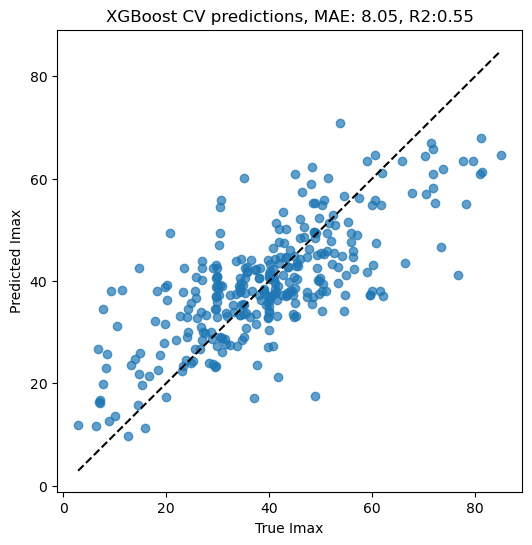

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(vY_Imax, y_pred, alpha=0.7)

plt.plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title(f"XGBoost CV predictions, MAE: {mae:.2f}, R2:{r2:.2f}")

plt.show()

In [27]:
log_vp_df = pd.read_csv('data/waka_with_imputed_vp.csv')
merged_waka_vp = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    log_vp_df[['CID', 'log_vp']],
    on='CID',
    how='left'
)
X46 = X45.copy()
X46['log_vp'] = merged_waka_vp['log_vp']
X46

,MPC08,ATS6m,Vindex,Eig07_AEA_dm_,VE1_A,Mor05m,SpMaxA_AEA_dm_,VE2_B_m_,Mor08m,SpMax1_Bh_m_,...,SdsCH,HGM,H6s,ATSC8e,Mor17v,VE2_G_D,Eig06_AEA_dm_,Eig02_EA_dm_,Mor02v,log_vp
0,0.000,0.000,1.088,0.000,2.309,-0.902,0.742,0.381,-0.489,3.595,...,0.000,17.798,0.000,0.000,-0.193,0.227,0.000,0.280,6.971,-0.163905
1,0.000,0.113,0.573,-1.505,2.718,-1.519,0.373,0.341,-0.422,3.838,...,0.833,11.541,0.000,0.000,-0.042,0.196,-1.000,0.000,9.002,-0.001051
2,0.000,0.202,0.573,-1.350,2.718,-1.409,0.344,0.334,-0.706,3.829,...,0.000,13.896,0.000,0.000,-0.055,0.176,-1.000,0.000,9.280,-1.004329
3,2.944,1.040,0.431,-0.382,3.169,-2.181,0.302,0.288,-0.899,3.921,...,3.170,9.233,0.000,0.000,0.056,0.195,0.730,0.000,10.808,-3.008774
4,0.000,1.627,0.487,-1.000,3.095,-1.867,0.277,0.276,-0.761,3.890,...,0.865,9.804,0.100,0.097,-0.177,0.180,-0.271,0.000,11.502,-1.254028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,3.932,3.017,0.313,1.451,3.959,-4.298,0.178,0.204,-1.868,3.876,...,2.392,5.139,1.312,0.074,-0.706,0.121,1.718,0.680,20.581,-3.410876
308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.911308
309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.911308
310,4.290,2.815,0.290,1.035,3.401,-1.535,0.208,0.220,-2.098,3.997,...,4.464,6.778,1.202,0.090,-0.536,0.142,1.353,0.828,20.608,-3.239050


In [28]:
y_pred_46 = cross_val_predict(
    best_xgb,
    X46,
    vY_Imax,
    cv=cv
)

In [29]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_46 = mean_absolute_error(vY_Imax, y_pred_46)
r2_46 = r2_score(vY_Imax, y_pred_46)

print(f"MAE = {mae_46:.3f}")
print(f"R²  = {r2_46:.3f}")

MAE = 7.858
R²  = 0.566


In [30]:
# now we try to add boiling point
bp_df = pd.read_csv('data/waka_with_imputed_bp.csv')
merged_waka_bp = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    bp_df[['CID', 'bp_value']],
    on='CID',
    how='left'
)
X47 = X46.copy()
X47['bp'] = merged_waka_bp['bp_value']
X47

,MPC08,ATS6m,Vindex,Eig07_AEA_dm_,VE1_A,Mor05m,SpMaxA_AEA_dm_,VE2_B_m_,Mor08m,SpMax1_Bh_m_,...,HGM,H6s,ATSC8e,Mor17v,VE2_G_D,Eig06_AEA_dm_,Eig02_EA_dm_,Mor02v,log_vp,bp
0,0.000,0.000,1.088,0.000,2.309,-0.902,0.742,0.381,-0.489,3.595,...,17.798,0.000,0.000,-0.193,0.227,0.000,0.280,6.971,-0.163905,147.500000
1,0.000,0.113,0.573,-1.505,2.718,-1.519,0.373,0.341,-0.422,3.838,...,11.541,0.000,0.000,-0.042,0.196,-1.000,0.000,9.002,-0.001051,178.889000
2,0.000,0.202,0.573,-1.350,2.718,-1.409,0.344,0.334,-0.706,3.829,...,13.896,0.000,0.000,-0.055,0.176,-1.000,0.000,9.280,-1.004329,205.500000
3,2.944,1.040,0.431,-0.382,3.169,-2.181,0.302,0.288,-0.899,3.921,...,9.233,0.000,0.000,0.056,0.195,0.730,0.000,10.808,-3.008774,299.000000
4,0.000,1.627,0.487,-1.000,3.095,-1.867,0.277,0.276,-0.761,3.890,...,9.804,0.100,0.097,-0.177,0.180,-0.271,0.000,11.502,-1.254028,153.796459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,3.932,3.017,0.313,1.451,3.959,-4.298,0.178,0.204,-1.868,3.876,...,5.139,1.312,0.074,-0.706,0.121,1.718,0.680,20.581,-3.410876,301.520307
308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.911308,185.012383
309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.911308,185.012383
310,4.290,2.815,0.290,1.035,3.401,-1.535,0.208,0.220,-2.098,3.997,...,6.778,1.202,0.090,-0.536,0.142,1.353,0.828,20.608,-3.239050,297.571641


In [31]:
y_pred_47 = cross_val_predict(
    best_xgb,
    X47,
    vY_Imax,
    cv=cv
)

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_47 = mean_absolute_error(vY_Imax, y_pred_47)
r2_47 = r2_score(vY_Imax, y_pred_47)

print(f"MAE = {mae_47:.3f}")
print(f"R²  = {r2_47:.3f}")

MAE = 7.999
R²  = 0.551


In [33]:
print(
    (waka_dragon_df['CID'].values ==
     merged_waka_bp['CID'].values).all()
)

True


In [34]:
merged_waka_bp['bp_value'].corr(
    merged_waka_vp['log_vp']
)

np.float64(-0.581191132403692)

In [35]:
importance_vp = pd.Series(
    best_xgb.fit(X46, vY_Imax).feature_importances_,
    index=X46.columns
).sort_values(ascending=False)

print(importance_vp.head(20))

log_vp            0.037879
Vindex            0.031314
ATSC8e            0.027728
Mor08m            0.026021
SpMaxA_AEA_dm_    0.025425
RDF010s           0.025237
H2m               0.024939
Mor17v            0.024010
VE2_B_m_          0.023994
MPC08             0.022659
SM15_AEA_bo_      0.022651
RDF065s           0.022634
Mor11v            0.022455
SpMax2_Bh_s_      0.022279
Mor03v            0.022134
Mor31u            0.021816
Eig07_AEA_dm_     0.021794
VE2_G_D           0.021665
Eig09_AEA_ri_     0.021661
P_VSA_LogP_3      0.021615
dtype: float32


In [36]:
X46

,MPC08,ATS6m,Vindex,Eig07_AEA_dm_,VE1_A,Mor05m,SpMaxA_AEA_dm_,VE2_B_m_,Mor08m,SpMax1_Bh_m_,...,SdsCH,HGM,H6s,ATSC8e,Mor17v,VE2_G_D,Eig06_AEA_dm_,Eig02_EA_dm_,Mor02v,log_vp
0,0.000,0.000,1.088,0.000,2.309,-0.902,0.742,0.381,-0.489,3.595,...,0.000,17.798,0.000,0.000,-0.193,0.227,0.000,0.280,6.971,-0.163905
1,0.000,0.113,0.573,-1.505,2.718,-1.519,0.373,0.341,-0.422,3.838,...,0.833,11.541,0.000,0.000,-0.042,0.196,-1.000,0.000,9.002,-0.001051
2,0.000,0.202,0.573,-1.350,2.718,-1.409,0.344,0.334,-0.706,3.829,...,0.000,13.896,0.000,0.000,-0.055,0.176,-1.000,0.000,9.280,-1.004329
3,2.944,1.040,0.431,-0.382,3.169,-2.181,0.302,0.288,-0.899,3.921,...,3.170,9.233,0.000,0.000,0.056,0.195,0.730,0.000,10.808,-3.008774
4,0.000,1.627,0.487,-1.000,3.095,-1.867,0.277,0.276,-0.761,3.890,...,0.865,9.804,0.100,0.097,-0.177,0.180,-0.271,0.000,11.502,-1.254028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,3.932,3.017,0.313,1.451,3.959,-4.298,0.178,0.204,-1.868,3.876,...,2.392,5.139,1.312,0.074,-0.706,0.121,1.718,0.680,20.581,-3.410876
308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.911308
309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.911308
310,4.290,2.815,0.290,1.035,3.401,-1.535,0.208,0.220,-2.098,3.997,...,4.464,6.778,1.202,0.090,-0.536,0.142,1.353,0.828,20.608,-3.239050


In [37]:
X46['log_vp']

0     -0.163905
1     -0.001051
2     -1.004329
3     -3.008774
4     -1.254028
         ...   
307   -3.410876
308   -3.911308
309   -3.911308
310   -3.239050
311   -2.689690
Name: log_vp, Length: 312, dtype: float64

In [38]:
y_pred_log_vp = cross_val_predict(
    best_xgb,
    X46[['log_vp']],
    vY_Imax,
    cv=cv
)

In [39]:
mae_log_vp = mean_absolute_error(vY_Imax, y_pred_log_vp)
r2_log_vp = r2_score(vY_Imax, y_pred_log_vp)

print(f"MAE = {mae_log_vp:.3f}")
print(f"R²  = {r2_log_vp:.3f}")

MAE = 9.988
R²  = 0.331


| Model               | MAE      | R²        |
| ------------------- | -------- | --------- |
| log_vp only         | **9.99** | **0.331** |
| Top45 Dragon        | ~8.05    | ~0.55     |
| Top45 + log_vp      | **7.86** | **0.566** |
| Top45 + log_vp + bp | 8.00     | 0.551     |


Here is a concise project-style summary that you can place directly into your notebook.

### Summary of Current Results

The objective of this study is to predict the odor intensity parameter **Imax** of 312 odorant molecules using molecular descriptors and machine learning.

#### Feature Selection

Initial experiments used feature importance derived from an XGBoost classifier. To better align feature selection with the regression objective, feature importance was recalculated using an **XGBoost Regressor** trained on the Dragon descriptor dataset. The top-ranked descriptors were then evaluated in subsets of increasing size.

Cross-validated evaluation showed that the best performance was obtained using approximately **45 descriptors**, suggesting that additional descriptors contribute little useful information and may introduce noise.

#### XGBoost Regression

Using the Top-45 Dragon descriptors, a hyperparameter search was performed for XGBoost regression. The best model parameters were:

```python
{
    'colsample_bytree': 0.7,
    'learning_rate': 0.03,
    'max_depth': 2,
    'n_estimators': 800,
    'subsample': 0.7
}
```

The resulting model achieved:

* Cross-validated MAE ≈ **7.87**
* Cross-validated R² ≈ **0.56**

The prediction scatter plot showed reasonable agreement between predicted and measured Imax values, although the model tends to overestimate very weak odorants and underestimate very strong odorants.

#### Effect of Vapor Pressure

To test whether volatility contributes information beyond Dragon descriptors, an additional feature containing experimental/imputed **log vapor pressure (log_vp)** was added to the Top-45 descriptor set.

Results:

| Feature Set            | MAE      | R²        |
| ---------------------- | -------- | --------- |
| Top-45 Dragon          | ~8.05    | ~0.55     |
| Top-45 Dragon + log_vp | **7.86** | **0.566** |

The addition of vapor pressure produced a consistent improvement in both MAE and R².

Feature importance analysis further revealed that **log_vp became the single most important feature** in the model, indicating that volatility plays a major role in odor intensity prediction.

#### Effect of Boiling Point

An additional experiment included imputed boiling point values together with the Top-45 descriptors and vapor pressure.

Results:

| Feature Set          | MAE      | R²        |
| -------------------- | -------- | --------- |
| Top-45 + log_vp      | **7.86** | **0.566** |
| Top-45 + log_vp + BP | 8.00     | 0.551     |

Boiling point did not improve model performance and slightly degraded prediction accuracy. This suggests that boiling point either provides information already captured by vapor pressure and Dragon descriptors or introduces additional noise due to prediction uncertainty in the imputed values.

#### Contribution of Vapor Pressure Alone

To quantify the standalone predictive power of volatility, a model was trained using only log vapor pressure:

| Feature Set | MAE  | R²    |
| ----------- | ---- | ----- |
| log_vp only | 9.99 | 0.331 |

This result shows that vapor pressure alone is insufficient to explain odor intensity. However, when combined with structural descriptors, it provides complementary information that improves prediction accuracy.

#### Current Best Model

The best-performing model identified so far uses:

* Top-45 Dragon descriptors selected by XGBoost Regressor importance
* Log vapor pressure (log_vp)

Performance:

* **MAE ≈ 7.86**
* **R² ≈ 0.566**

These results support the hypothesis that odor intensity depends on both:

1. **Molecular transport to the receptor** (represented by vapor pressure)
2. **Molecular interaction with the receptor** (represented by Dragon structural descriptors)

Future work will focus on model interpretation (e.g., SHAP analysis) and further investigation of the physicochemical factors governing odor intensity.


In [40]:
import shap

In [41]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X46)

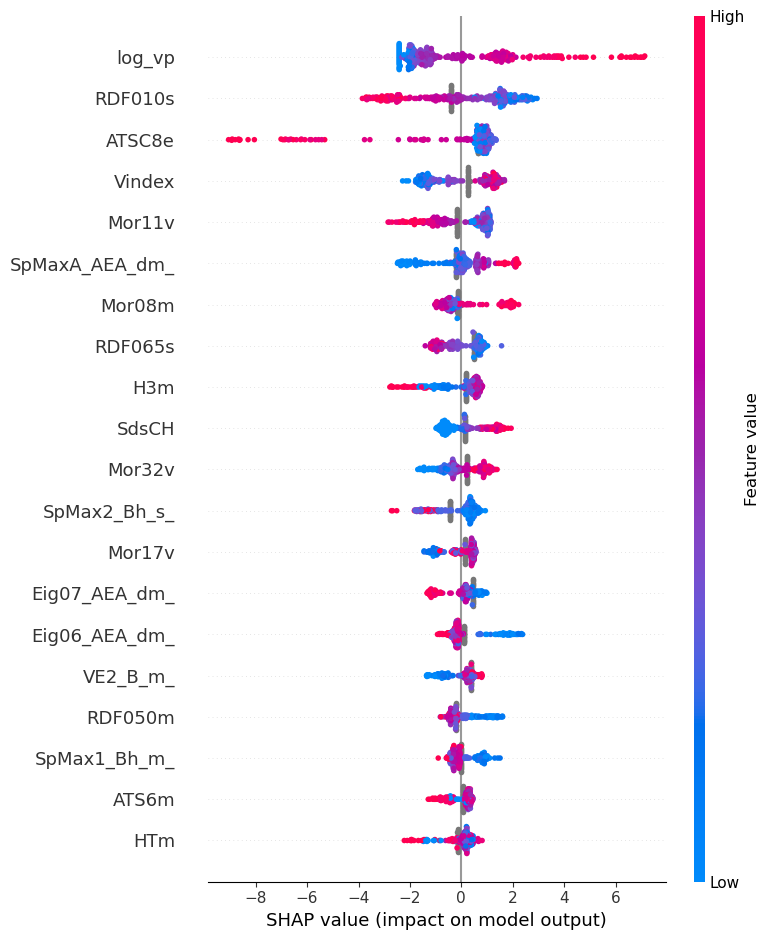

In [42]:
shap.summary_plot(
    shap_values,
    X46
)

In [43]:
shap_importance = pd.DataFrame({
    'feature': X46.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    'mean_abs_shap',
    ascending=False
)

print(shap_importance.head(20))

           feature  mean_abs_shap
45          log_vp       1.934330
16         RDF010s       1.619972
39          ATSC8e       1.424231
2           Vindex       1.135773
26          Mor11v       0.945652
6   SpMaxA_AEA_dm_       0.750179
8           Mor08m       0.737879
10         RDF065s       0.684254
35             H3m       0.683522
36           SdsCH       0.676677
34          Mor32v       0.622141
29    SpMax2_Bh_s_       0.571042
40          Mor17v       0.489036
3    Eig07_AEA_dm_       0.481584
42   Eig06_AEA_dm_       0.470334
7         VE2_B_m_       0.462804
24         RDF050m       0.415270
9     SpMax1_Bh_m_       0.359306
1            ATS6m       0.354050
18             HTm       0.349121


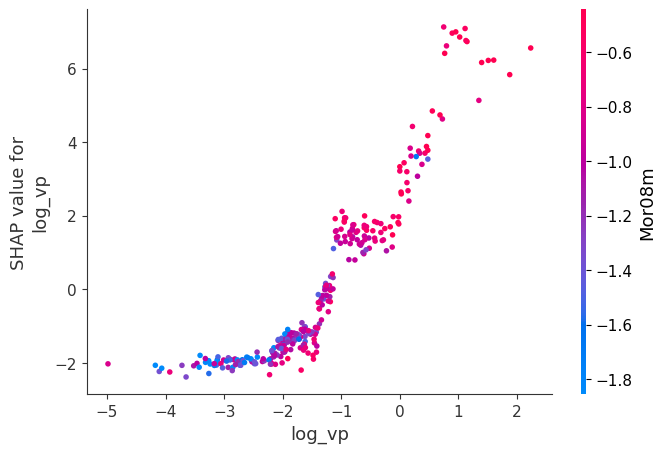

In [44]:
shap.dependence_plot(
    'log_vp',
    shap_values,
    X46
)

In [45]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    merged_waka_vp['log_vp'],
    vY_Imax
)

spearman_r, spearman_p = spearmanr(
    merged_waka_vp['log_vp'],
    vY_Imax
)

print(f"Pearson r  = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}")

Pearson r  = 0.598
Spearman r = 0.598


In [46]:
from catboost import CatBoostRegressor

In [47]:
cat_model = CatBoostRegressor(
    loss_function='MAE',
    iterations=1000,
    depth=4,
    learning_rate=0.03,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

In [48]:
y_pred_cat = cross_val_predict(
    cat_model,
    X46,
    vY_Imax,
    cv=cv
)

mae_cat = mean_absolute_error(vY_Imax, y_pred_cat)
r2_cat = r2_score(vY_Imax, y_pred_cat)

print(f"CatBoost MAE = {mae_cat:.3f}")
print(f"CatBoost R²  = {r2_cat:.3f}")

CatBoost MAE = 8.052
CatBoost R²  = 0.557


In [49]:
X_int = X46.copy()

X_int['log_vp_x_Vindex'] = (
    X_int['log_vp']
    * X_int['Vindex']
)

X_int['log_vp_x_Mor08m'] = (
    X_int['log_vp']
    * X_int['Mor08m']
)

X_int['log_vp_x_RDF010s'] = (
    X_int['log_vp']
    * X_int['RDF010s']
)

In [50]:
y_pred_int = cross_val_predict(
    best_xgb,
    X_int,
    vY_Imax,
    cv=cv
)

mae_int = mean_absolute_error(
    vY_Imax,
    y_pred_int
)

r2_int = r2_score(
    vY_Imax,
    y_pred_int
)

print(f"MAE = {mae_int:.3f}")
print(f"R²  = {r2_int:.3f}")

MAE = 7.982
R²  = 0.550


In [51]:
best_xgb.fit(X_int, vY_Imax)

importance_int = pd.Series(
    best_xgb.feature_importances_,
    index=X_int.columns
).sort_values(ascending=False)

print(importance_int.head(15))

log_vp              0.038867
Vindex              0.032191
log_vp_x_RDF010s    0.029761
SpMaxA_AEA_dm_      0.026249
log_vp_x_Mor08m     0.026028
H2m                 0.025951
ATSC8e              0.024838
Mor17v              0.023900
Mor08m              0.023177
Eig09_AEA_ri_       0.023052
SM12_AEA_dm_        0.022977
SdsCH               0.022664
RDF010s             0.022578
Mor11v              0.022501
HTm                 0.020451
dtype: float32


In [52]:
results_df = pd.DataFrame({
    'CID': waka_dragon_df['CID'],
    'Name': waka_dragon_df['Name'],
    'Imax_true': vY_Imax,
    'Imax_pred': y_pred_46
})

results_df['abs_error'] = (
    results_df['Imax_true']
    - results_df['Imax_pred']
).abs()

worst20 = (
    results_df
    .sort_values('abs_error', ascending=False)
    .head(20)
)

worst20

,CID,Name,Imax_true,Imax_pred,abs_error
79,8175,decanal,76.62,43.240524,33.379476
307,16070752,karanal,48.88,19.188988,29.691012
98,8857,ethyl acetate,35.06,64.148232,29.088232
277,5352481,beta-ionone epoxide,9.25,37.262573,28.012573
35,7391,p-tert-butylcyclohexanol,11.41,39.220867,27.810867
195,93375,triplal,73.42,45.713585,27.706415
270,5283345,trans-2-decenal,20.82,47.648464,26.828464
26,7007,rosephenone,7.79,34.411541,26.621541
238,240122,guaiyl acetate,14.76,40.798210,26.038210
231,163336,undecavertol,61.49,37.262573,24.227427


In [53]:
rd_kit_df = pd.read_csv('data/waka_rdkit_expert_features.csv')
rd_kit_df

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308,16204527,isocyclocitral,304.474,4.8474,34.14,0.0,2.0,2.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,19871663,terpirosa,144.258,2.4395,20.23,1.0,1.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:

merged_waka_rd_kit = pd.merge(
    waka_dragon_df[['CID', 'Name']],
    rd_kit_df.drop(columns='Name'),
    on='CID',
    how='left'
)
merged_waka_rd_kit

,CID,Name,rdkit_MolWt,rdkit_MolLogP,rdkit_TPSA,rdkit_NumHDonors,rdkit_NumHAcceptors,rdkit_NumRotatableBonds,rdkit_RingCount,rdkit_NumAromaticRings,...,has_aldehyde,has_alpha_beta_unsat_aldehyde,has_ketone,has_ester,has_alcohol,has_phenol,has_carboxylic_acid,has_sulfur,has_nitrogen,has_aromatic_ring
0,179,acetoin,88.106,-0.0438,37.30,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,240,benzaldehyde,106.124,1.4991,17.07,0.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,244,benzyl alcohol,108.140,1.1789,20.23,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,323,coumarin,146.145,1.7930,30.21,0.0,2.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,326,cumin aldehyde,148.205,2.6225,17.07,0.0,1.0,2.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,16070752,karanal,266.425,4.4041,18.46,0.0,2.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
308,16204527,isocyclocitral,304.474,4.8474,34.14,0.0,2.0,2.0,2.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
309,19871663,terpirosa,144.258,2.4395,20.23,1.0,1.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
310,44153588,tricyclodecenyl butyrate,220.312,2.9304,26.30,0.0,2.0,3.0,3.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
X_rdkit = pd.concat(
    [
        X46.reset_index(drop=True),
        merged_waka_rd_kit.drop(columns=['CID', 'Name']).reset_index(drop=True)
    ],
    axis=1
)

print(X46.shape)
print(X_rdkit.shape)

(312, 46)
(312, 66)


In [57]:
duplicate_cols = X_rdkit.columns[
    X_rdkit.columns.duplicated()
]

print(duplicate_cols)

Index([], dtype='str')


In [58]:
y_pred_rdkit = cross_val_predict(
    best_xgb,
    X_rdkit,
    vY_Imax,
    cv=cv
)

mae_rdkit = mean_absolute_error(
    vY_Imax,
    y_pred_rdkit
)

r2_rdkit = r2_score(
    vY_Imax,
    y_pred_rdkit
)

print(f"MAE = {mae_rdkit:.3f}")
print(f"R² = {r2_rdkit:.3f}")

MAE = 7.874
R² = 0.566


In [59]:
best_xgb.fit(X_rdkit, vY_Imax)

importance_rdkit = pd.Series(
    best_xgb.feature_importances_,
    index=X_rdkit.columns
).sort_values(ascending=False)

importance_rdkit.head(30)

log_vp                0.038109
Mor08m                0.026900
SpMaxA_AEA_dm_        0.024525
rdkit_MolWt           0.023903
VE2_B_m_              0.020893
ATSC8e                0.020424
has_aldehyde          0.020201
Mor17v                0.019920
RDF065s               0.019497
Vindex                0.018926
Eig07_AEA_dm_         0.018882
Eig09_AEA_ri_         0.018851
Mor11v                0.018439
RDF010s               0.018181
rdkit_NumHDonors      0.018033
Eig06_AEA_dm_         0.017399
RDF050m               0.017265
H3m                   0.017211
SpMax1_Bh_m_          0.017167
SpMax2_Bh_s_          0.016844
has_alcohol           0.016792
H2m                   0.016773
rdkit_FractionCSP3    0.016718
Mor32v                0.016694
P_VSA_LogP_3          0.016683
SM05_AEA_dm_          0.016518
HGM                   0.016467
SdsCH                 0.016400
has_ester             0.016336
Eig02_EA_dm_          0.016289
dtype: float32

In [60]:
rdkit_cols = [
    col for col in X_rdkit.columns
    if col.startswith('rdkit_')
    or col.startswith('has_')
]

importance_rdkit[
    importance_rdkit.index.isin(rdkit_cols)
].head(20)

rdkit_MolWt                      0.023903
has_aldehyde                     0.020201
rdkit_NumHDonors                 0.018033
has_alcohol                      0.016792
rdkit_FractionCSP3               0.016718
has_ester                        0.016336
rdkit_MolLogP                    0.015129
rdkit_NumRotatableBonds          0.014719
rdkit_TPSA                       0.014591
rdkit_RingCount                  0.013870
rdkit_NumHAcceptors              0.013384
rdkit_NumAromaticRings           0.010072
rdkit_HeavyAtomCount             0.008474
has_alpha_beta_unsat_aldehyde    0.000000
has_ketone                       0.000000
has_phenol                       0.000000
has_carboxylic_acid              0.000000
has_sulfur                       0.000000
has_nitrogen                     0.000000
has_aromatic_ring                0.000000
dtype: float32

In [61]:
xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

In [62]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_rdkit_reg = XGBRegressor(
    objective='reg:absoluteerror',
    random_state=42,
    n_jobs=-1
)

param_grid_rdkit = {
    'max_depth': [2, 3],
    'learning_rate': [0.02, 0.03, 0.05],
    'n_estimators': [600, 800, 1000],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

grid_rdkit = GridSearchCV(
    estimator=xgb_rdkit_reg,
    param_grid=param_grid_rdkit,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rdkit.fit(X_rdkit, vY_Imax)

print("Best CV MAE:", -grid_rdkit.best_score_)
print("Best params:")
print(grid_rdkit.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best CV MAE: 7.754557983806668
Best params:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.8}


In [63]:
best_xgb_rdkit = XGBRegressor(
    objective='reg:absoluteerror',
    **grid_rdkit.best_params_,
    random_state=42,
    n_jobs=-1
)

In [64]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_rdkit_best = cross_val_predict(
    best_xgb_rdkit,
    X_rdkit,
    vY_Imax,
    cv=cv
)

mae_rdkit_best = mean_absolute_error(vY_Imax, y_pred_rdkit_best)
r2_rdkit_best = r2_score(vY_Imax, y_pred_rdkit_best)

print(f"MAE = {mae_rdkit_best:.3f}")
print(f"R²  = {r2_rdkit_best:.3f}")

MAE = 7.867
R²  = 0.562


In [65]:
res_df = pd.DataFrame({
    'CID': waka_dragon_df['CID'],
    'Name': waka_dragon_df['Name'],
    'Imax_true': vY_Imax,
    'Imax_pred': y_pred_46,
    'has_aldehyde': merged_waka_rd_kit['has_aldehyde'],
    'has_alpha_beta_unsat_aldehyde': merged_waka_rd_kit['has_alpha_beta_unsat_aldehyde']
})

res_df['residual'] = res_df['Imax_true'] - res_df['Imax_pred']
res_df['abs_error'] = res_df['residual'].abs()

res_df.groupby('has_aldehyde')[['residual', 'abs_error']].describe()

residual                                                      \
                count      mean        std        min       25%       50%   
has_aldehyde                                                                
0.0             268.0 -0.968658   9.827040 -29.088232 -7.052291 -1.032865   
1.0              44.0  5.793332  11.258581 -26.828464 -0.649248  4.131432   

                                   abs_error                                \
                    75%        max     count      mean       std       min   
has_aldehyde                                                                 
0.0            4.936510  29.691012     268.0  7.593438  6.295735  0.058179   
1.0           13.055445  33.379476      44.0  9.470141  8.326441  0.619478   

                                                        
                   25%       50%        75%        max  
has_aldehyde                                            
0.0           2.639005  5.604048  11.177182  29.691012  
1.0           3.631484  6.032637  13.413255  33.379476

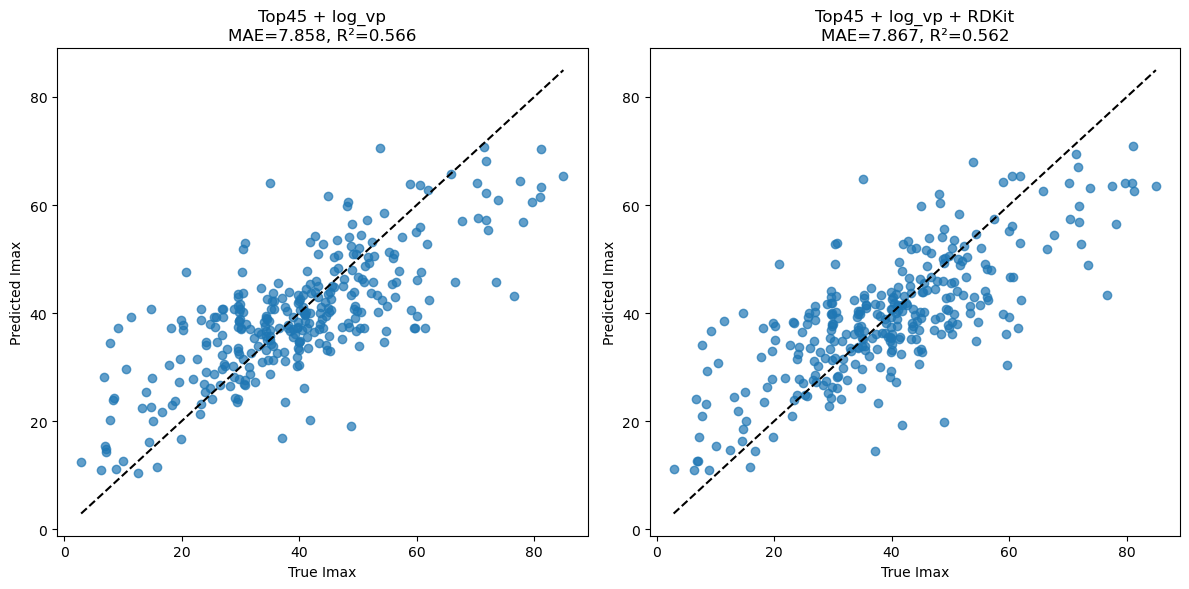

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 6)
)

# Model 1
ax[0].scatter(
    vY_Imax,
    y_pred_46,
    alpha=0.7
)

ax[0].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[0].set_title(
    'Top45 + log_vp\nMAE=7.858, R²=0.566'
)

ax[0].set_xlabel('True Imax')
ax[0].set_ylabel('Predicted Imax')

# Model 2
ax[1].scatter(
    vY_Imax,
    y_pred_rdkit_best,
    alpha=0.7
)

ax[1].plot(
    [vY_Imax.min(), vY_Imax.max()],
    [vY_Imax.min(), vY_Imax.max()],
    '--k'
)

ax[1].set_title(
    'Top45 + log_vp + RDKit\nMAE=7.867, R²=0.562'
)

ax[1].set_xlabel('True Imax')
ax[1].set_ylabel('Predicted Imax')

plt.tight_layout()
plt.show()

In [67]:
residual_46 = vY_Imax - y_pred_46
residual_rdkit = vY_Imax - y_pred_rdkit_best

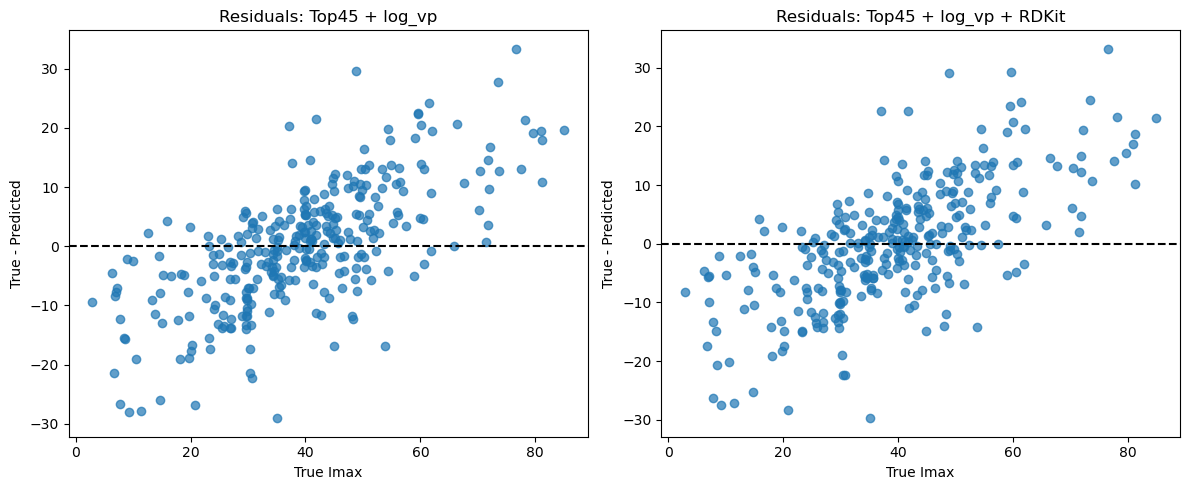

In [68]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

ax[0].scatter(
    vY_Imax,
    residual_46,
    alpha=0.7
)

ax[0].axhline(0, linestyle='--', color='k')
ax[0].set_title('Residuals: Top45 + log_vp')
ax[0].set_xlabel('True Imax')
ax[0].set_ylabel('True - Predicted')

ax[1].scatter(
    vY_Imax,
    residual_rdkit,
    alpha=0.7
)

ax[1].axhline(0, linestyle='--', color='k')
ax[1].set_title('Residuals: Top45 + log_vp + RDKit')
ax[1].set_xlabel('True Imax')
ax[1].set_ylabel('True - Predicted')

plt.tight_layout()
plt.show()